# Levaraging Weak Learners Using Adaptive Boosting
# How it works:
    1. draw a random sample of training examples, d1, without replacement from the training dataset D to train a weak learner C1
    2. Draw 2nd random sample training datasets d2, without replacement from the training dataset and add 50% of the examples that were iniitially misclassified to train weak learner C2
    3. find the trainning data that bothe C1 and C2 disagrees on to train a 3rd weak Learner C3
    4. Combine the weak learners C1,C2,C3 majority voting



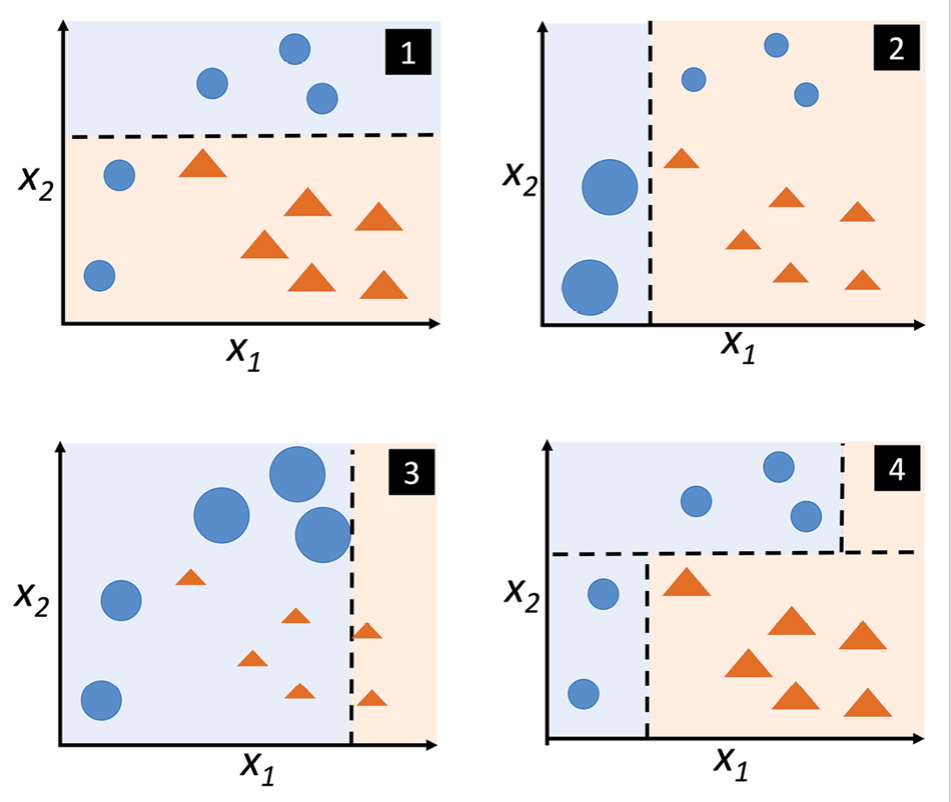
The subfigure 1, which represents a training dataset for binary classification where all training examples are assigned equal weights. Based on this training dataset, we train a decision stump (shown as a dashed line) that tries to classify the examples of the two classes (triangles and circles), as well as possibly minimizing the loss function (or the impurity score in the special case of decision tree ensembles).
    
For the next round (subfigure 2), we assign a larger weight to the two previously misclassified examples (circles). Furthermore, we lower the weight of the correctly classified examples. The next decision stump will now be more focused on the training examples that have the largest weights—the training examples that are supposedly hard to classify. 
   
   
The weak learner shown in subfigure 2 misclassifies three different examples from the circle class, which are then assigned a larger weight, as shown in subfigure 3.
    
we then combine the three weak learners trained on different reweighted training subsets by a weighted majority vote, as shown in subfigure 4.

# Adaboost Step by step:
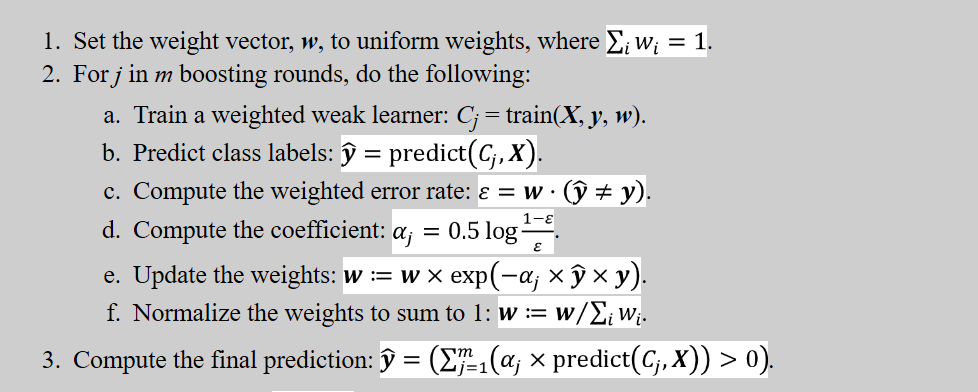
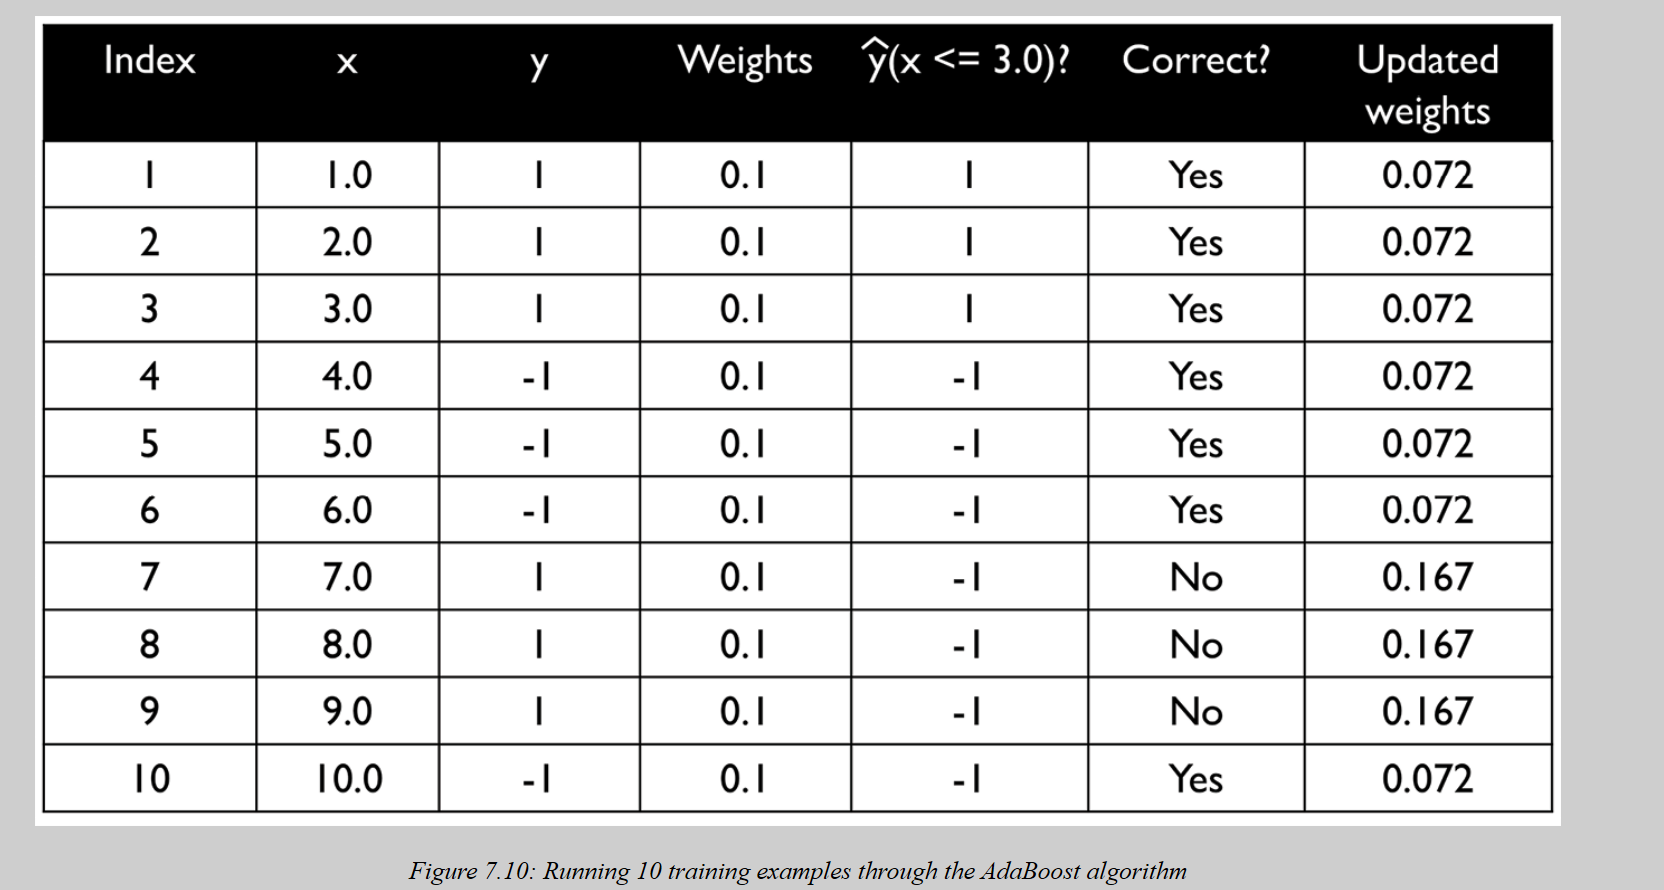

In [ ]:
# IMplementation
import numpy as np
y = np.array([1,1,1,1,1,-1,-1,-1,-1,1])
yhat = np.array([1,1,1,1,-1,1,-1,1,-1,1])

correct = (yhat == y)
weights = np.full(10,0.1)
print(weights)

epil = np.mean(~correct)
print(epil)

a_j = 0.5 * np.log((1-epil)/epil)

print(a_j)

# Upd_weigt = w * (-a_j * yhat * y)
# if preditvtion is correct we will decrease weight else increase

update_if_wrong = 0.1 * np.exp(-a_j * -1* 1)

update_if_correct = 0.1 *np.exp(-a_j * 1*1)

#print(update_if_wrong)

weights = np.where( correct == 1, update_if_correct, update_if_wrong)

#print(weights)
# Lets try normalizing

norm_weights = weights/np.sum(weights)

print(norm_weights)
#Normalizing weights



[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
0.3
0.42364893019360184
[0.06546537 0.06546537 0.06546537 0.06546537 0.15275252 0.15275252
 0.06546537 0.15275252 0.06546537 0.06546537]
[0.07142857 0.07142857 0.07142857 0.07142857 0.16666667 0.16666667
 0.07142857 0.16666667 0.07142857 0.07142857]


In [1]:
# APPLYINH ADABOOST USING SCIKIT LEARN

from sklearn import datasets
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

iris = datasets.load_iris()
X,y = iris.data[50:, [1,2]], iris.target[50:]

#print(X)
le = LabelEncoder()
y = le.fit_transform(y)
#print(y)

x_train,x_test, y_train, y_test = train_test_split(X,y, test_size= 0.5, stratify= y, random_state= 21)




In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier(criterion= 'gini', max_depth= 1, random_state= 21)

ada = AdaBoostClassifier(estimator= tree, n_estimators= 500, learning_rate= 0.1, random_state= 1)

tree =  tree.fit(x_train, y_train)

y_pred_test = tree.predict(x_test)

y_pred_train = tree.predict(x_train)

y_predtrain_acuracy = accuracy_score(y_pred_train, y_train)
y_predtest_acuracy = accuracy_score(y_pred_test, y_test)

print(f"The y train/test {y_predtrain_acuracy} {y_predtest_acuracy}")

#the margin of test and train is smaller meaning it does not overfit




The y train/test 0.92 0.94


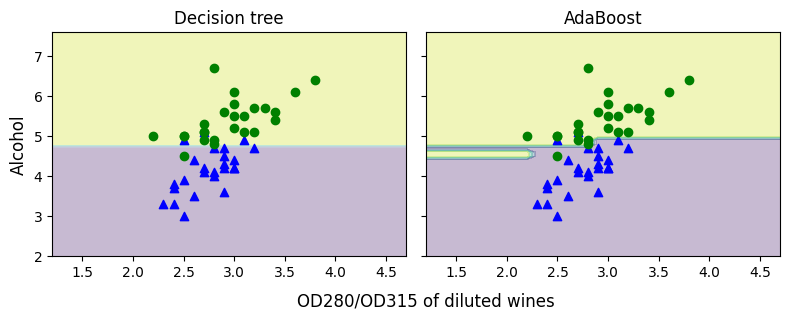

In [5]:
import matplotlib.pyplot as plt
import numpy as np

x_min = x_train[:, 0].min() - 1
x_max = x_train[:, 0].max() + 1
y_min = x_train[:, 1].min() - 1
y_max = x_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),np.arange(y_min, y_max, 0.1))

f, axarr = plt.subplots(1, 2,sharex='col',sharey='row',figsize=(8, 3))

for idx, clf, tt in zip([0, 1],[tree, ada],['Decision tree', 'AdaBoost']):
    clf.fit(x_train, y_train)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axarr[idx].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx].scatter(x_train[y_train==0, 0],x_train[y_train==0, 1],c='blue', marker='^')
    axarr[idx].scatter(x_train[y_train==1, 0],x_train[y_train==1, 1],c='green', marker='o')
    axarr[idx].set_title(tt)
    axarr[0].set_ylabel('Alcohol', fontsize=12)
   
plt.tight_layout()
plt.text(0, -0.2,s='OD280/OD315 of diluted wines',ha='center',va='center',fontsize=12,transform=axarr[1].transAxes)
plt.show()

